In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [2]:
X01 = np.array([[0, 1, 0],
                [1, 0, 0],
                [0, 0, 0]], dtype = complex)
    
Y01 = np.array([[0, -1j, 0],
                [1j, 0, 0],
                [0, 0, 0]], dtype = complex)
    
X12 = np.array([[0, 0, 0],
                [0, 0, 1],
                [0, 1, 0]], dtype = complex)
    
Y12 = np.array([[0, 0, 0],
                [0, 0, -1j],
                [0, 1j, 0]], dtype = complex)

In [3]:
p0 = 1.0
rho0 = np.array([[p0, 0, 0],
                [0, 1-p0, 0],
                [0, 0, 0]], 
               dtype = complex)

In [4]:
w01 = 2*np.pi * 4.391e9 # GHz
anh = 2*np.pi * -0.181e9 # GHz
lamb01 = 1.0
lamb12 = 2**(1/2)

w12 = w01 + anh

In [5]:
def constantWF(_t):
    return 1
def gaussianWF(_t, _mu, _sigma):
    return np.exp(-(_t - _mu)**2/(2*_sigma**2))

In [6]:
def get_H(_t, _wd, _V0, _phi, _s):
    dw01 = w01 - _wd
    dw12 = w12 - _wd
    I = np.cos(_phi)
    Q = np.sin(_phi)
    return (_V0/2) * _s(_t) * (lamb01 * ( (-I * np.sin(dw01 * _t) + Q * np.cos(dw01 * _t)) * Y01
                                       -(I * np.cos(dw01 * _t) + Q * np.sin(dw01 * _t)) * X01)
                             + lamb12 * ( (-I * np.sin(dw12 * _t) + Q * np.cos(dw12 * _t)) * Y12
                                       -(I * np.cos(dw12 * _t) + Q * np.sin(dw12 * _t)) * X12))
def get_U(_t, _dt, _wd, _V0, _phi, _s):
    return la.expm(-1j * get_H(_t, _wd, _V0, _phi, _s) * _dt)

# Discretization approximation

In [7]:
T = 200e-9
V0 = np.pi/(T * lamb01)
wd = w01
phi = 0
def s(_t):
    return constantWF(_t)
    

steps = 1000
times = np.linspace(0, T, steps)
dt = T/float(steps)

rho = rho0.copy()
pops = np.zeros((3, steps))

for i in range(steps):
    U = get_U(times[i], dt, wd, V0, phi, s)
    rho = np.matmul(U, np.matmul(rho, U.T.conj()))
    pops[:, i] = np.diag(np.real(rho))
    

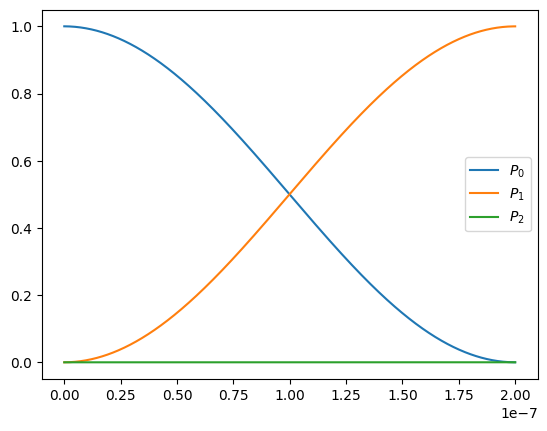

In [8]:
plt.plot(times, pops[0,:], label = r'$P_0$')
plt.plot(times, pops[1,:], label = r'$P_1$')
plt.plot(times, pops[2,:], label = r'$P_2$')
plt.legend()

In [9]:
def simulate(_steps, _wd, _T, _V0, _phi, _s):
    _times = np.linspace(0, _T, _steps)
    _dt = _T/float(_steps)
    _rho = rho0.copy()
    U = np.array([[1, 0, 0],
                  [0, 1, 0],
                  [0, 0, 1]])
    for jt in range(_steps):
        U = get_U(_times[jt], _dt, _wd, _V0, _phi, _s)@U
    _rho = U @ _rho @ U.T.conj()
    return np.diag(np.real(_rho))
    

In [10]:
from tqdm import tqdm
T = 50e-9
V0 = np.pi/(T*lamb01)
phi = 0.0
def s(_t):
    return constantWF(_t)
tsteps = 1000

dw_steps = 1000
dw_lim = 2*np.pi * 0.25e9
dw = np.linspace(-dw_lim, dw_lim, dw_steps)

In [11]:
# pops = np.zeros((3, dw_steps))
# for i in tqdm(range(dw_steps)):
#     pops[:,i] = simulate(tsteps, w01+ dw[i], T, V0, phi, s)


In [12]:
# freqs = (w01+dw)/(2*np.pi)
# plt.plot(freqs, pops[0,:], label = r'$P_0$')
# plt.plot(freqs, pops[1,:], label = r'$P_1$')
# plt.plot(freqs, pops[2,:], label = r'$P_2$')
# plt.legend()

# RK45 solver

In [13]:
from scipy.integrate import RK45
def solve(_func, _T, _y0):
    solver = RK45(fun = _func, 
                      t0 = 0.0, 
                      y0 = _y0, 
                      t_bound = _T,
                      rtol = 1e-4,
                      atol = 1e-7)
        
    y_points = []
    t_points = []
    while solver.status == 'running':
        solver.step() 
        y_points.append(solver.y.copy())
        t_points.append(solver.t)
    y_points = np.array(y_points, dtype = complex)
    t_points = np.array(t_points)
    return t_points, y_points

In [14]:
def func(_t, _y):
    _rho = _y.reshape(3,3)
    H = get_H(_t, wd, V0, phi, s)
    _res = -1j * (H @ _rho - _rho @ H)
    return _res.reshape(1,9)[0]

In [15]:
times, ys = solve(func, T, rho0.reshape(1,9)[0])
print(len(times))

52


In [16]:
pops = np.zeros((3, len(times)))
for i in range(len(times)):
    pops[:,i] = np.diag(np.real(ys[i].reshape(3,3)))

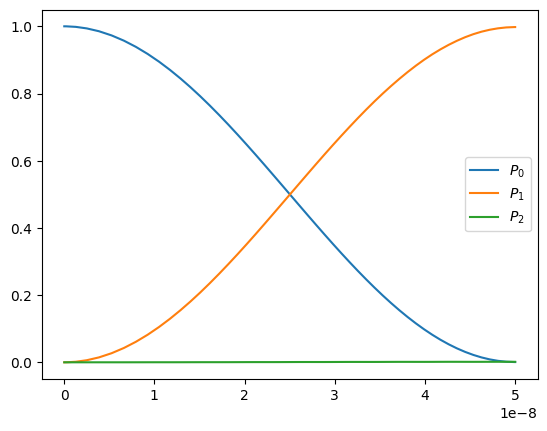

In [17]:
plt.plot(times, pops[0,:], label = r'$P_0$')
plt.plot(times, pops[1,:], label = r'$P_1$')
plt.plot(times, pops[2,:], label = r'$P_2$')
plt.legend()

In [18]:
T = 50e-9
V0 = np.pi/(T*lamb01)
phi = 0.0
def s(_t):
    return constantWF(_t)

dw_steps = 1000
dw_lim = 2*np.pi * 0.25e9
dw = np.linspace(-dw_lim, dw_lim, dw_steps)

In [19]:
from tqdm import tqdm

pops = np.zeros((3, dw_steps))
for i in tqdm(range(dw_steps)):
    wd = w01+ dw[i]
    times, ys = solve(func, T, rho0.reshape(1,9)[0])
    yf = ys[-1]
    pops[:,i] = np.diag(np.real(yf.reshape(3,3)))

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 98.80it/s]


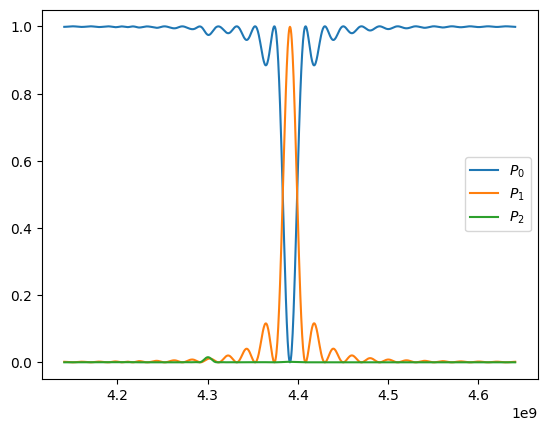

In [20]:
freqs = (w01+dw)/(2*np.pi)
plt.plot(freqs, pops[0,:], label = r'$P_0$')
plt.plot(freqs, pops[1,:], label = r'$P_1$')
plt.plot(freqs, pops[2,:], label = r'$P_2$')
plt.legend()

# Full-spectroscopy

In [21]:
print(np.pi/(V0*lamb01))

5e-08


In [22]:
T = 200e-9
V0 = 2*np.pi * 50e6
phi = 0.0
def s(_t):
    return constantWF(_t)
tsteps = 75
times = np.linspace(0.0, T, tsteps)

dw_steps = 300
dw_lim = 2*np.pi * 0.25e9
dw = np.linspace(-dw_lim, dw_lim, dw_steps)

In [23]:
from tqdm import tqdm

pops = np.zeros((tsteps, dw_steps))
for i in tqdm(range(dw_steps)):
    for j in range(tsteps):
        wd = w01+ dw[i]
        _, ys = solve(func, times[j], rho0.reshape(1,9)[0])
        yf = ys[-1]
        pops[j, i] = np.diag(np.real(yf.reshape(3,3)))[0]

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [12:38<00:00,  2.53s/it]


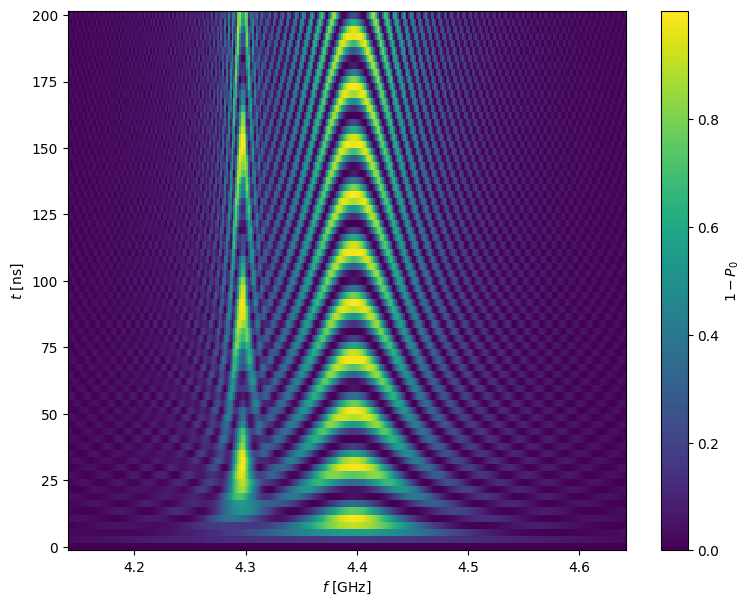

In [24]:
freqs = (w01+dw)/(2*np.pi)

fig, ax = plt.subplots(figsize=(9,7))

pcm = ax.pcolormesh(freqs*1e-9, times*1e9,  1-pops) 

fig.colorbar(pcm, label=r'$1-P_0$')
ax.set_ylabel(r'$t$ [ns]')
ax.set_xlabel(r'$f$ [GHz]')

plt.show()

In [25]:
((w01+w12)/3)/(2*np.pi)

2866999999.9999995